<a href="https://colab.research.google.com/github/sara-iqbal/Demand-Forecasting-Engine/blob/main/demand_forecasting_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Forecasting Engine
### Retail + Energy · ARIMA · Prophet · LSTM · Multi-Horizon

**Author:** Sara Iqbal | MSc Data Science

In [1]:
# Step 1 — Imports
!pip install prophet scikit-learn torch pandas numpy matplotlib statsmodels -q
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, json, warnings
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.spines.top':False,'axes.spines.right':False,
    'font.family':'DejaVu Sans','axes.grid':True,'grid.alpha':0.4})
print("Ready")

Ready


In [2]:
# Step 2 — Synthetic Retail + Energy Datasets
# Realistic time series with trend, seasonality, noise, and events

dates = pd.date_range('2021-01-01','2024-12-31', freq='D')
n = len(dates)

# --- Retail demand (daily units sold) ---
trend_r = np.linspace(800, 1200, n)
weekly  = 150 * np.sin(2*np.pi*np.arange(n)/7)
yearly  = 300 * np.sin(2*np.pi*np.arange(n)/365 - np.pi/2)
events  = np.zeros(n)
# Black Friday / Christmas spikes
for i,d in enumerate(dates):
    if d.month==11 and d.day==25: events[i]=800
    if d.month==12 and 20<=d.day<=26: events[i]=600
    if d.month==1  and d.day<=3:  events[i]=-300
noise_r = np.random.normal(0,60,n)
retail  = (trend_r + weekly + yearly + events + noise_r).clip(0)

# --- Energy consumption (kWh/hour, daily avg) ---
trend_e = np.linspace(450, 520, n)
weekly_e= 40*np.sin(2*np.pi*np.arange(n)/7 + np.pi)
temp_e  = 80*np.cos(2*np.pi*np.arange(n)/365)
noise_e = np.random.normal(0,20,n)
energy  = (trend_e + weekly_e + temp_e + noise_e).clip(0)

retail_df = pd.DataFrame({'ds':dates,'y':retail.round(0),'type':'retail'})
energy_df = pd.DataFrame({'ds':dates,'y':energy.round(1),'type':'energy'})

print(f"Retail series:  {len(retail_df)} days, mean={retail.mean():.0f}, std={retail.std():.0f}")
print(f"Energy series:  {len(energy_df)} days, mean={energy.mean():.1f}, std={energy.std():.1f}")
retail_df.head()

Retail series:  1461 days, mean=1014, std=279
Energy series:  1461 days, mean=485.4, std=68.7


,ds,y,type
0,2021-01-01,230.0,retail
1,2021-01-02,309.0,retail
2,2021-01-03,386.0,retail
3,2021-01-04,658.0,retail
4,2021-01-05,423.0,retail


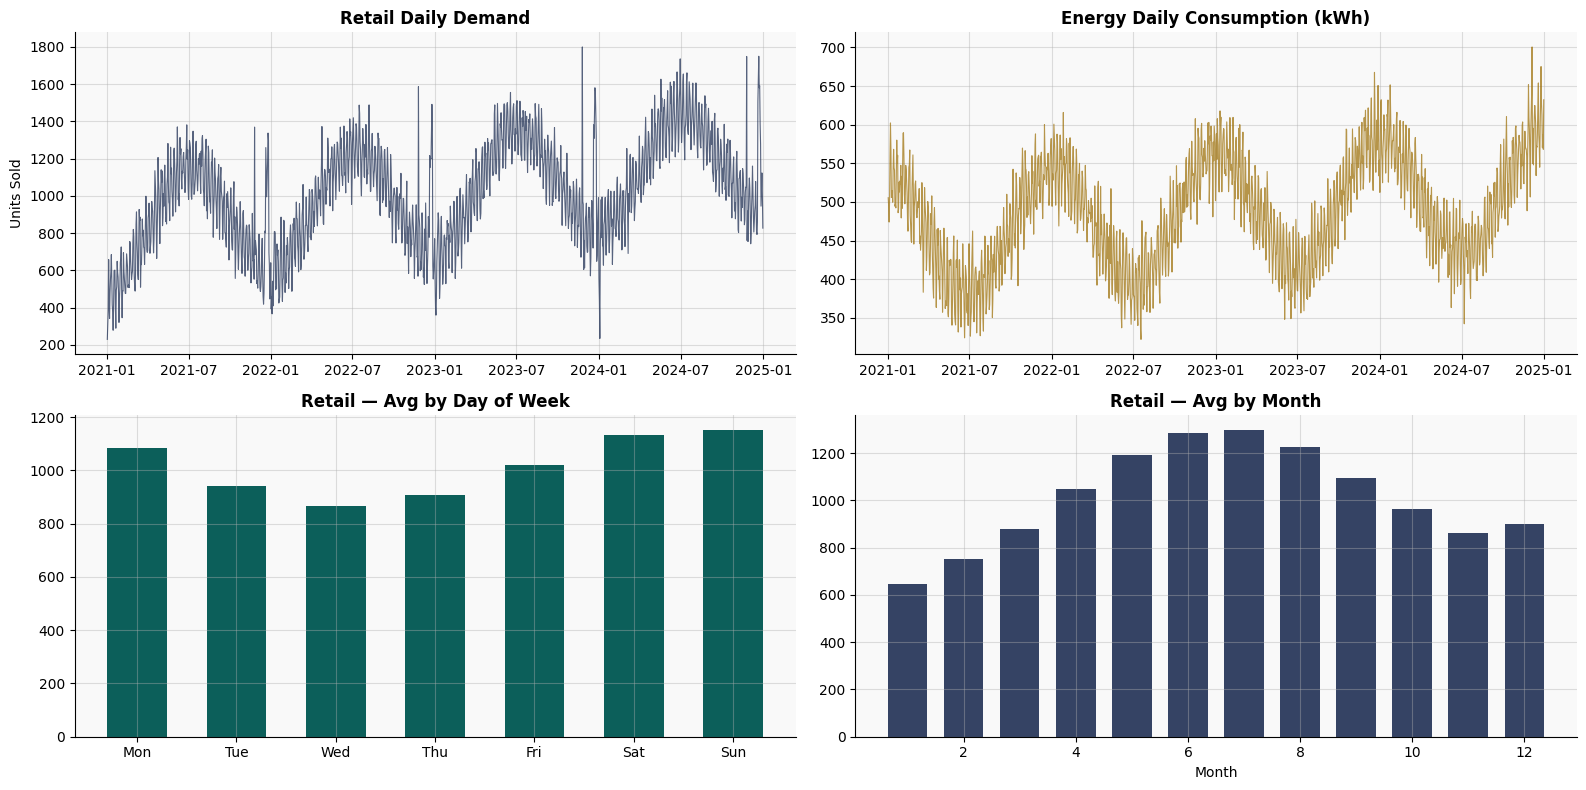

In [3]:
# Step 3 — EDA: Trend, Seasonality, ACF

fig, axes = plt.subplots(2, 2, figsize=(16,8))
NAVY='#12234A'; GOLD='#9A6B00'; TEAL='#0C5F5A'

axes[0,0].plot(retail_df['ds'], retail_df['y'], color=NAVY, lw=0.8, alpha=0.7)
axes[0,0].set_title('Retail Daily Demand', fontweight='bold')
axes[0,0].set_ylabel('Units Sold')

axes[0,1].plot(energy_df['ds'], energy_df['y'], color=GOLD, lw=0.8, alpha=0.7)
axes[0,1].set_title('Energy Daily Consumption (kWh)', fontweight='bold')

# Weekly pattern
retail_df['dow'] = retail_df['ds'].dt.dayofweek
axes[1,0].bar(range(7), retail_df.groupby('dow')['y'].mean(),
              color=TEAL, width=0.6)
axes[1,0].set_xticks(range(7))
axes[1,0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1,0].set_title('Retail — Avg by Day of Week', fontweight='bold')

# Monthly pattern
retail_df['month'] = retail_df['ds'].dt.month
axes[1,1].bar(range(1,13), retail_df.groupby('month')['y'].mean(),
              color=NAVY, width=0.7, alpha=0.85)
axes[1,1].set_title('Retail — Avg by Month', fontweight='bold')
axes[1,1].set_xlabel('Month')
plt.tight_layout()
plt.savefig('demand_eda.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# Step 4 — Train/Test Split + ARIMA Baseline
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

HORIZON = 30  # forecast 30 days ahead
train_r = retail_df['y'].values[:-HORIZON]
test_r  = retail_df['y'].values[-HORIZON:]

print("Fitting ARIMA(5,1,2) on retail demand...")
arima = ARIMA(train_r, order=(5,1,2))
arima_fit = arima.fit()
arima_fc  = arima_fit.forecast(steps=HORIZON)

arima_mae  = mean_absolute_error(test_r, arima_fc)
arima_rmse = np.sqrt(mean_squared_error(test_r, arima_fc))
arima_mape = np.mean(np.abs((test_r - arima_fc)/(test_r+1e-9)))*100

print(f"ARIMA MAE:  {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA MAPE: {arima_mape:.2f}%")

Fitting ARIMA(5,1,2) on retail demand...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA MAE:  174.12
ARIMA RMSE: 302.81
ARIMA MAPE: 12.62%


In [5]:
# Step 5 — Prophet Forecast
from prophet import Prophet

print("Fitting Prophet on retail demand...")
prophet_df = retail_df[['ds','y']].copy()
train_prop = prophet_df.iloc[:-HORIZON]

m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
            daily_seasonality=False, seasonality_mode='multiplicative',
            changepoint_prior_scale=0.1)
m.fit(train_prop)

future = m.make_future_dataframe(periods=HORIZON)
forecast = m.predict(future)
prophet_fc = forecast['yhat'].values[-HORIZON:]

prophet_mae  = mean_absolute_error(test_r, prophet_fc)
prophet_rmse = np.sqrt(mean_squared_error(test_r, prophet_fc))
prophet_mape = np.mean(np.abs((test_r-prophet_fc)/(test_r+1e-9)))*100

print(f"Prophet MAE:  {prophet_mae:.2f}")
print(f"Prophet RMSE: {prophet_rmse:.2f}")
print(f"Prophet MAPE: {prophet_mape:.2f}%")

Fitting Prophet on retail demand...
Prophet MAE:  164.53
Prophet RMSE: 247.01
Prophet MAPE: 12.96%


In [6]:
# Step 6 — LSTM Forecast
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

# Normalise
mu_r, std_r = train_r.mean(), train_r.std()
train_norm = (train_r - mu_r) / std_r
SEQ = 30

X, y = create_sequences(train_norm, SEQ)
X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y_t = torch.tensor(y, dtype=torch.float32)
ds  = TensorDataset(X_t, y_t)
dl  = DataLoader(ds, batch_size=32, shuffle=True)

class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc   = nn.Sequential(nn.Linear(64,32),nn.ReLU(),nn.Linear(32,1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:,-1]).squeeze()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
lstm = LSTMForecaster().to(DEVICE)
opt  = torch.optim.Adam(lstm.parameters(), lr=1e-3)
crit = nn.MSELoss()

print("Training LSTM...")
for epoch in range(30):
    lstm.train()
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = crit(lstm(xb), yb)
        loss.backward()
        opt.step()
    if (epoch+1)%10==0:
        print(f"  Epoch {epoch+1}/30 loss={loss.item():.5f}")

# Autoregressive forecast
lstm.eval()
seed = torch.tensor(train_norm[-SEQ:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(DEVICE)
preds_norm = []
with torch.no_grad():
    inp = seed.clone()
    for _ in range(HORIZON):
        p = lstm(inp).item()
        preds_norm.append(p)
        new = torch.tensor([[[p]]], dtype=torch.float32).to(DEVICE)
        inp = torch.cat([inp[:,1:,:], new], dim=1)

lstm_fc   = np.array(preds_norm)*std_r + mu_r
lstm_mae  = mean_absolute_error(test_r, lstm_fc)
lstm_rmse = np.sqrt(mean_squared_error(test_r, lstm_fc))
lstm_mape = np.mean(np.abs((test_r-lstm_fc)/(test_r+1e-9)))*100
print(f"LSTM MAE:  {lstm_mae:.2f}  RMSE: {lstm_rmse:.2f}  MAPE: {lstm_mape:.2f}%")

Training LSTM...
  Epoch 10/30 loss=0.17356
  Epoch 20/30 loss=0.13873
  Epoch 30/30 loss=0.06178
LSTM MAE:  183.64  RMSE: 257.93  MAPE: 15.19%


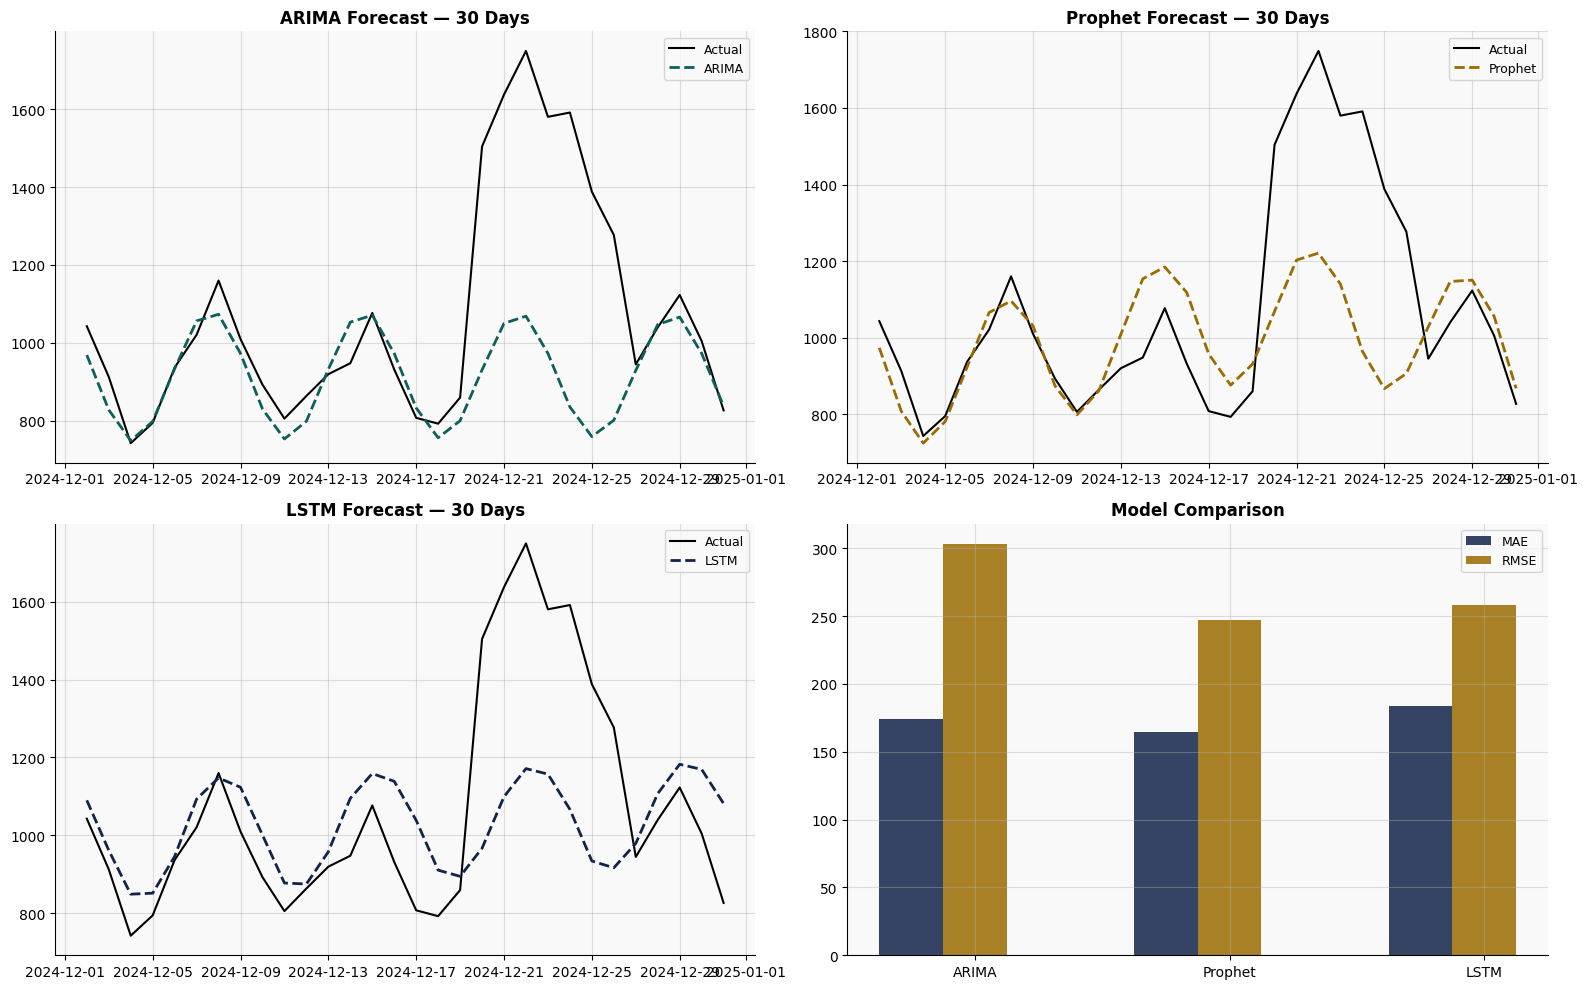

Best model: ARIMA


In [7]:
# Step 7 — Results Visualisation + Export

fig, axes = plt.subplots(2,2,figsize=(16,10))
NAVY='#12234A';GOLD='#9A6B00';TEAL='#0C5F5A';GREEN='#145232';RED='#8B2020'
test_dates = retail_df['ds'].values[-HORIZON:]

for ax, fc, name, col in [(axes[0,0],arima_fc,'ARIMA',TEAL),
                           (axes[0,1],prophet_fc,'Prophet',GOLD),
                           (axes[1,0],lstm_fc,'LSTM',NAVY)]:
    ax.plot(test_dates, test_r,  color='black', lw=1.5, label='Actual')
    ax.plot(test_dates, fc, color=col, lw=2, ls='--', label=name)
    ax.set_title(f'{name} Forecast — 30 Days', fontweight='bold')
    ax.legend(fontsize=9)

# Model comparison
models_n = ['ARIMA','Prophet','LSTM']
maes  = [arima_mae,  prophet_mae,  lstm_mae]
rmses = [arima_rmse, prophet_rmse, lstm_rmse]
mapes = [arima_mape, prophet_mape, lstm_mape]
x = np.arange(3); w=0.25
axes[1,1].bar(x-w, maes,  w, label='MAE',  color=NAVY, alpha=0.85)
axes[1,1].bar(x,   rmses, w, label='RMSE', color=GOLD, alpha=0.85)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(models_n)
axes[1,1].set_title('Model Comparison', fontweight='bold')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('demand_results.png',dpi=150,bbox_inches='tight')
plt.show()

dashboard2 = {
    'models': {
        'ARIMA':   {'mae':round(arima_mae,2),'rmse':round(arima_rmse,2),'mape':round(arima_mape,2),'forecast':[round(float(v),1) for v in arima_fc]},
        'Prophet': {'mae':round(prophet_mae,2),'rmse':round(prophet_rmse,2),'mape':round(prophet_mape,2),'forecast':[round(float(v),1) for v in prophet_fc]},
        'LSTM':    {'mae':round(lstm_mae,2),'rmse':round(lstm_rmse,2),'mape':round(lstm_mape,2),'forecast':[round(float(v),1) for v in lstm_fc]},
    },
    'actual': [round(float(v),1) for v in test_r],
    'dates':  [str(d)[:10] for d in test_dates],
    'train_series': {'retail':[round(float(v),0) for v in retail[-90:]], 'energy':[round(float(v),1) for v in energy[-90:]]},
}
with open('demand_data.json','w') as f: json.dump(dashboard2,f,indent=2)
print("Best model:", min(zip(['ARIMA','Prophet','LSTM'],[arima_mape,prophet_mape,lstm_mape]),key=lambda x:x[1])[0])